<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/BOA008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

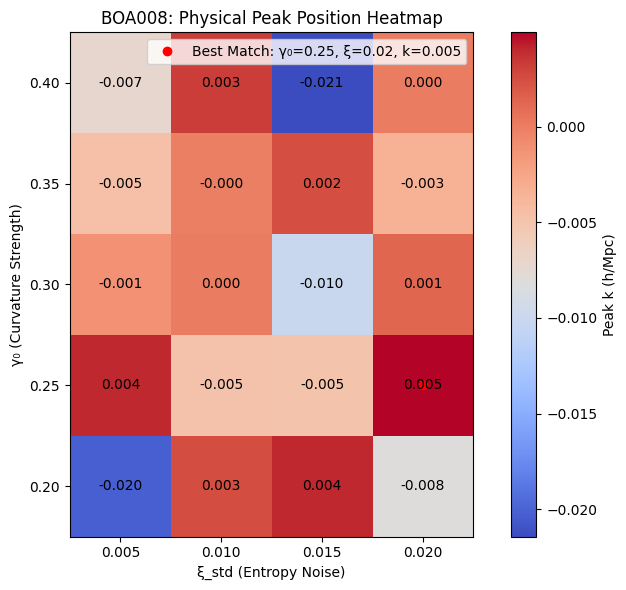

In [1]:
# BOA008: Inverse sweep to target BAO scale in HES
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit

# Parameters
N = 256
dt = 0.01
steps = 300
kappa = 0.1
delta = 0.05
epsilon = 0.005
gamma_vals = [0.2, 0.25, 0.3, 0.35, 0.4]
xi_vals = [0.005, 0.01, 0.015, 0.02]
target_k = 0.025  # h/Mpc
scale_factor = 0.0067 / 0.139  # from BOA007

# Gaussian fit function
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Sweep
peak_matrix = np.zeros((len(gamma_vals), len(xi_vals)))
for i, gamma_0 in enumerate(gamma_vals):
    for j, xi_std in enumerate(xi_vals):
        A = np.random.normal(0, 0.1, (N, N))
        for t in range(steps):
            xi = np.random.normal(0, xi_std, (N, N))
            laplacian = (
                np.roll(A, 1, 0) + np.roll(A, -1, 0) +
                np.roll(A, 1, 1) + np.roll(A, -1, 1) - 4 * A
            )
            dA = (-kappa * A + delta * A**2 + epsilon * A**3 + gamma_0 * laplacian + xi) * dt
            A += np.nan_to_num(dA)

        fft_A = fftshift(fft2(A))
        power_spectrum = np.abs(fft_A)**2
        y, x = np.indices((N, N))
        center = (N // 2, N // 2)
        r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
        r = r.astype(np.int32)
        tbin = np.bincount(r.ravel(), power_spectrum.ravel())
        nr = np.bincount(r.ravel())
        radial_ps = tbin / (nr + 1e-10)
        k_vals = np.arange(len(radial_ps)) / (N / 2)
        radial_ps_smooth = gaussian_filter(radial_ps, sigma=2)

        fit_mask = (k_vals > 0.15) & (k_vals < 0.35)
        k_fit = k_vals[fit_mask]
        ps_fit = radial_ps_smooth[fit_mask]
        try:
            popt, _ = curve_fit(gaussian, k_fit, ps_fit, p0=[np.max(ps_fit), 0.25, 0.05])
            _, k0_lattice, _ = popt
            k0_physical = k0_lattice * scale_factor
            peak_matrix[i, j] = k0_physical
        except:
            peak_matrix[i, j] = np.nan

# Find best match
best_i, best_j = np.unravel_index(np.nanargmin(np.abs(peak_matrix - target_k)), peak_matrix.shape)
best_gamma = gamma_vals[best_i]
best_xi = xi_vals[best_j]
best_peak = peak_matrix[best_i, best_j]

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(peak_matrix, cmap='coolwarm', origin='lower')
for i in range(len(gamma_vals)):
    for j in range(len(xi_vals)):
        val = peak_matrix[i, j]
        label = f"{val:.3f}" if not np.isnan(val) else "nan"
        ax.text(j, i, label, ha="center", va="center", color="black")
ax.plot(best_j, best_i, 'ro', label=f'Best Match: γ₀={best_gamma}, ξ={best_xi}, k={best_peak:.3f}')
ax.set_xticks(np.arange(len(xi_vals)))
ax.set_yticks(np.arange(len(gamma_vals)))
ax.set_xticklabels([f"{x:.3f}" for x in xi_vals])
ax.set_yticklabels([f"{g:.2f}" for g in gamma_vals])
ax.set_xlabel("ξ_std (Entropy Noise)")
ax.set_ylabel("γ₀ (Curvature Strength)")
ax.set_title("BOA008: Physical Peak Position Heatmap")
fig.colorbar(im, ax=ax, label="Peak k (h/Mpc)")
ax.legend()
plt.tight_layout()
plt.show()
